In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
X=pd.read_csv("random.txt",sep=r"\s+",header=None)
X.columns=['x1','x2']

In [5]:
Y=pd.read_csv("green.txt",sep=r"\s+",header=None)
Y.columns=['y1','y2','y3']

In [6]:
df=pd.concat([X,Y],axis=1)

In [7]:
df.head()

,x1,x2,y1,y2,y3
0,3.920868e-07,0.509609,0.044084,0.259264,1.014065
1,3.525161e-01,13.338289,-0.003448,0.000787,-0.000106
2,9.630555e-01,16.765764,-0.001771,0.000326,-0.000085
3,3.353550e-01,18.306543,-0.001319,0.000218,-0.000049
4,7.958636e-01,16.653862,-0.001793,0.000331,-0.000086


In [8]:
df.tail()

,x1,x2,y1,y2,y3
25,0.731112,13.314620,-0.003563,0.000830,-0.000272
26,0.722074,4.229419,-0.411953,0.277892,1.152702
27,0.308252,5.259778,0.588657,1.247834,-4.793370
28,0.752296,10.995892,-0.006492,0.001862,-0.000764
29,0.636724,12.620207,-0.004174,0.001023,-0.000354


In [9]:
df.isnull()

,x1,x2,y1,y2,y3
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [10]:
df.isnull().sum()

x1    0
x2    0
y1    0
y2    0
y3    0
dtype: int64

In [11]:
df.describe()

,x1,x2,y1,y2,y3
count,3.000000e+01,30.000000,30.000000,30.000000,30.000000
mean,5.356767e-01,10.549103,0.159071,-0.170472,-0.430576
std,3.313435e-01,6.316589,0.477288,1.557948,2.202737
min,3.920868e-07,0.508404,-1.055627,-7.175158,-8.833026
25%,3.021947e-01,4.188654,-0.004719,0.000281,-0.002313
50%,5.977724e-01,12.687768,-0.001928,0.000808,-0.000096
75%,7.886647e-01,15.809142,0.071811,0.056967,0.041262
max,9.947433e-01,18.529034,1.547455,2.165378,3.760964


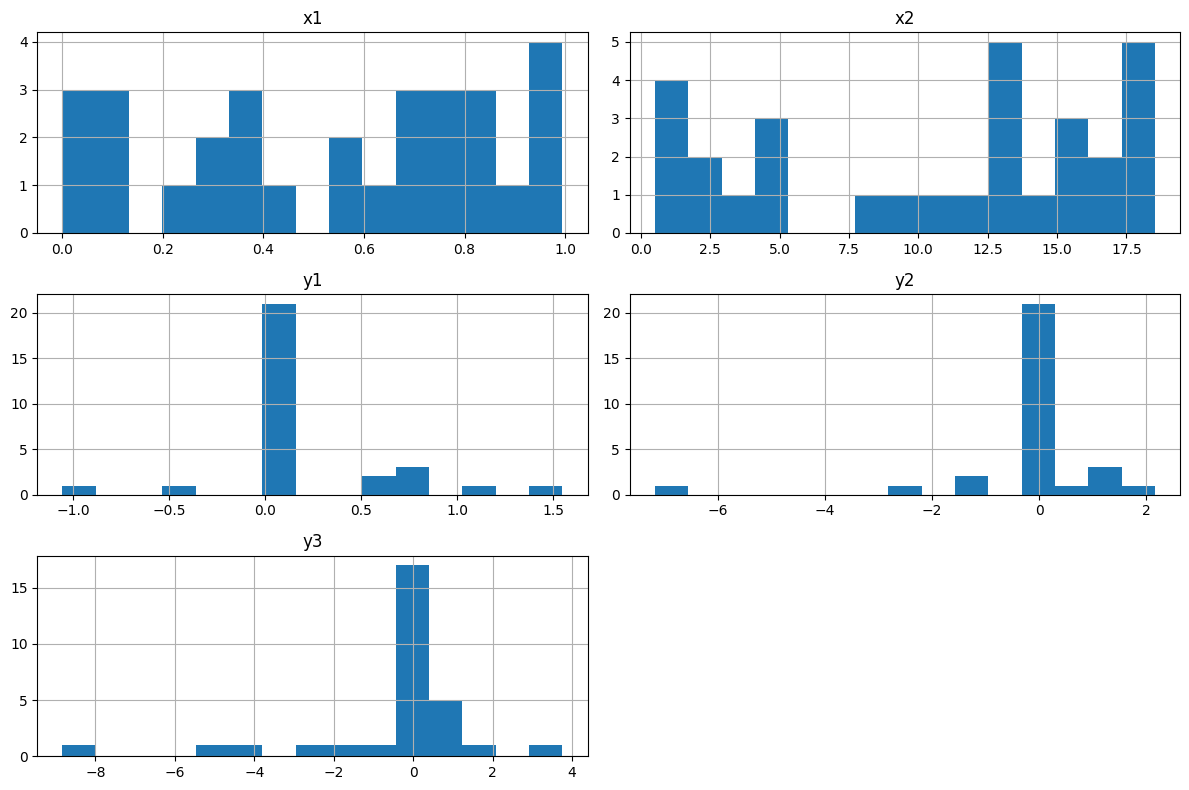

In [12]:
df.hist(figsize=(12,8),bins=15)
plt.tight_layout()

Text(0.5, 1.0, 'Boxplot Analysis')

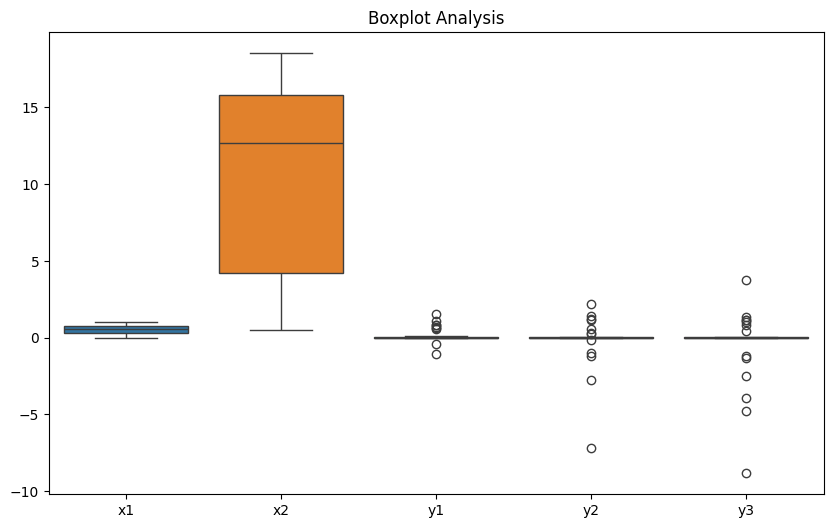

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.title("Boxplot Analysis")

In [14]:
corr=df.corr()

In [15]:
corr

,x1,x2,y1,y2,y3
x1,1.000000,0.115138,-0.142041,0.192607,0.290604
x2,0.115138,1.000000,-0.487587,0.014412,0.012109
y1,-0.142041,-0.487587,1.000000,-0.031395,-0.336161
y2,0.192607,0.014412,-0.031395,1.000000,0.725001
y3,0.290604,0.012109,-0.336161,0.725001,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

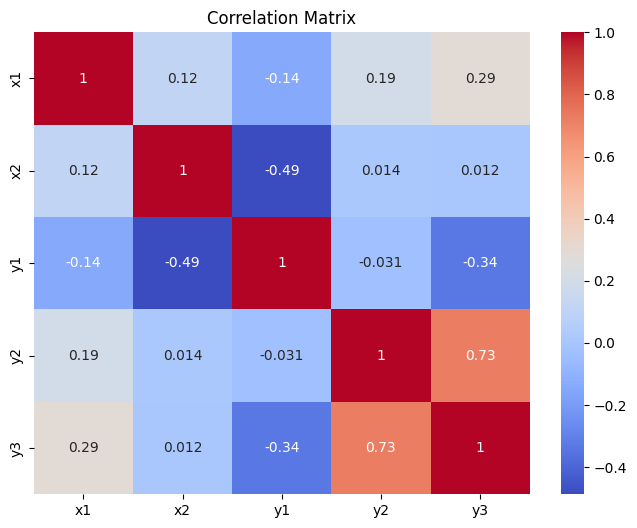

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.model_selection import KFold

In [19]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [20]:
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [21]:
lr_model = LinearRegression()

In [22]:
r2_scores = cross_val_score(
    lr_model,
    X_scaled,
    Y,
    cv=kf,
    scoring='r2'
)

print("R² Scores for each fold:\n")

print(r2_scores)

print("\nMean R²:")

print(np.mean(r2_scores))

R² Scores for each fold:

[-0.51305405 -0.57739912 -4.81055598 -5.84605207 -1.7397551 ]

Mean R²:
-2.697363265503187


In [23]:
mae_scores = cross_val_score(
    lr_model,
    X_scaled,
    Y,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

mae_scores = -mae_scores

print(mae_scores)

print(np.mean(mae_scores))

[0.96609914 1.65322701 0.41630557 0.42496289 0.9830577 ]
0.8887304605825553


In [24]:
mae_scores = cross_val_score(
    lr_model,
    X_scaled,
    Y,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

mae_scores = -mae_scores

print(mae_scores)

print(np.mean(mae_scores))

[0.96609914 1.65322701 0.41630557 0.42496289 0.9830577 ]
0.8887304605825553


In [25]:
rmse_scores = np.sqrt(
    -cross_val_score(
        lr_model,
        X_scaled,
        Y,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
)

print(rmse_scores)

print(np.mean(rmse_scores))

[1.40647368 3.03460754 0.70910312 0.58771486 1.42252136]
1.4320841101716535


In [26]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [28]:
r2_scores_rf = cross_val_score(
    rf_model,
    X,
    Y,
    cv=kf,
    scoring='r2'
)

print(r2_scores_rf)

print(np.mean(r2_scores_rf))

[-0.37053713 -0.15716544  0.22702377 -4.19496232 -4.4671255 ]
-1.7925533224377297


In [29]:
mae_scores_rf = -cross_val_score(
    rf_model,
    X,
    Y,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print(mae_scores_rf)

print(np.mean(mae_scores_rf))

[0.7086904  1.5200573  0.34015997 0.31430964 1.1893222 ]
0.814507899990123


In [30]:
rmse_scores_rf = np.sqrt(
    -cross_val_score(
        rf_model,
        X,
        Y,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
)

print(rmse_scores_rf)

print(np.mean(rmse_scores_rf))

[1.66970568 2.7799493  0.76448557 0.53946876 2.0489514 ]
1.56051214306408


In [31]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

In [32]:
gb_model = MultiOutputRegressor(

    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

)

In [33]:
r2_scores_gb = cross_val_score(
    gb_model,
    X,
    Y,
    cv=kf,
    scoring='r2'
)

print(r2_scores_gb)

print(np.mean(r2_scores_gb))

[-0.72173851 -0.35945208 -0.16302652 -3.08004807 -5.09410577]
-1.883674189972205


In [34]:
mae_scores_gb = -cross_val_score(
    gb_model,
    X,
    Y,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print(mae_scores_gb)

print(np.mean(mae_scores_gb))

[0.7740897  1.44288019 0.32168507 0.28541439 1.14272407]
0.7933586829434613


In [35]:
rmse_scores_gb = np.sqrt(
    -cross_val_score(
        gb_model,
        X,
        Y,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
)

print(rmse_scores_gb)

print(np.mean(rmse_scores_gb))

[1.88614487 2.66113548 0.89773637 0.62692824 2.21718464]
1.6578259194753457


In [36]:
lr_model.fit(X_scaled, Y)

lr_pred = lr_model.predict(X_scaled)

In [37]:
rf_model.fit(X, Y)

rf_pred = rf_model.predict(X)

In [38]:
gb_model.fit(X, Y)

gb_pred = gb_model.predict(X)

In [39]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [40]:
def evaluate_per_output(y_true, y_pred, model_name):

    outputs = ['y1', 'y2', 'y3']

    print(f"\n{model_name}\n")

    for i, output in enumerate(outputs):

        r2 = r2_score(
            y_true.iloc[:, i],
            y_pred[:, i]
        )

        mae = mean_absolute_error(
            y_true.iloc[:, i],
            y_pred[:, i]
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true.iloc[:, i],
                y_pred[:, i]
            )
        )

        print(f"{output}")

        print(f"R²   : {r2:.4f}")

        print(f"MAE  : {mae:.4f}")

        print(f"RMSE : {rmse:.4f}")

        print("-"*30)

In [41]:
evaluate_per_output(
    Y,
    lr_pred,
    "Linear Regression"
)


Linear Regression

y1
R²   : 0.2452
MAE  : 0.2488
RMSE : 0.4077
------------------------------
y2
R²   : 0.0372
MAE  : 0.8144
RMSE : 1.5030
------------------------------
y3
R²   : 0.0849
MAE  : 1.3338
RMSE : 2.0717
------------------------------


In [42]:
evaluate_per_output(
    Y,
    rf_pred,
    "Random Forest"
)


Random Forest

y1
R²   : 0.9209
MAE  : 0.0693
RMSE : 0.1320
------------------------------
y2
R²   : 0.7271
MAE  : 0.3656
RMSE : 0.8002
------------------------------
y3
R²   : 0.7602
MAE  : 0.5801
RMSE : 1.0606
------------------------------


In [43]:
evaluate_per_output(
    Y,
    gb_pred,
    "Gradient Boosting"
)


Gradient Boosting

y1
R²   : 0.9996
MAE  : 0.0058
RMSE : 0.0088
------------------------------
y2
R²   : 0.9972
MAE  : 0.0510
RMSE : 0.0812
------------------------------
y3
R²   : 0.9967
MAE  : 0.0798
RMSE : 0.1238
------------------------------


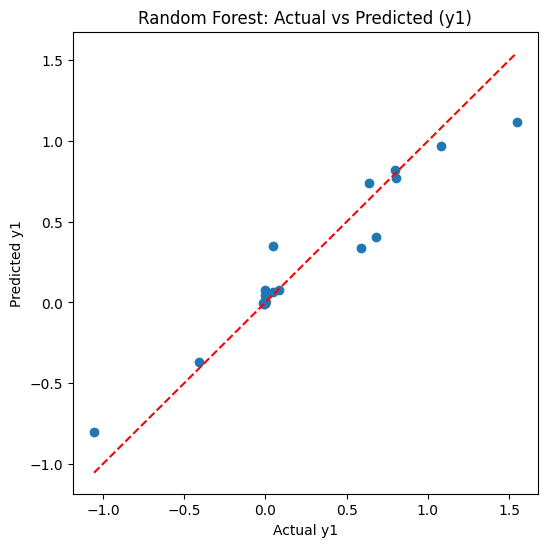

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    Y['y1'],
    rf_pred[:,0]
)

plt.plot(
    [Y['y1'].min(), Y['y1'].max()],
    [Y['y1'].min(), Y['y1'].max()],
    'r--'
)

plt.xlabel("Actual y1")

plt.ylabel("Predicted y1")

plt.title("Random Forest: Actual vs Predicted (y1)")

plt.show()

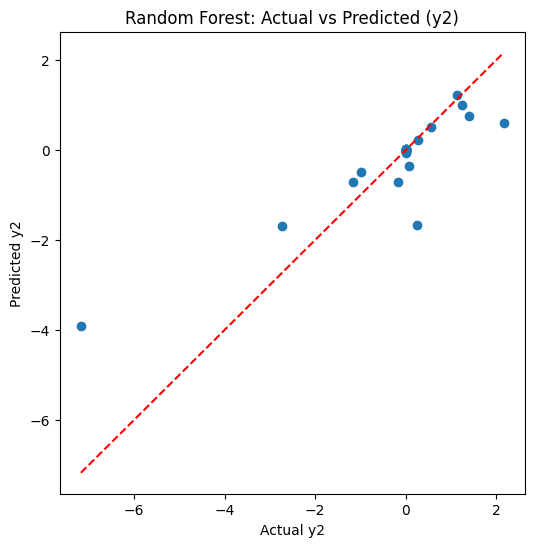

In [45]:
plt.figure(figsize=(6,6))

plt.scatter(
    Y['y2'],
    rf_pred[:,1]
)

plt.plot(
    [Y['y2'].min(), Y['y2'].max()],
    [Y['y2'].min(), Y['y2'].max()],
    'r--'
)

plt.xlabel("Actual y2")

plt.ylabel("Predicted y2")

plt.title("Random Forest: Actual vs Predicted (y2)")

plt.show()

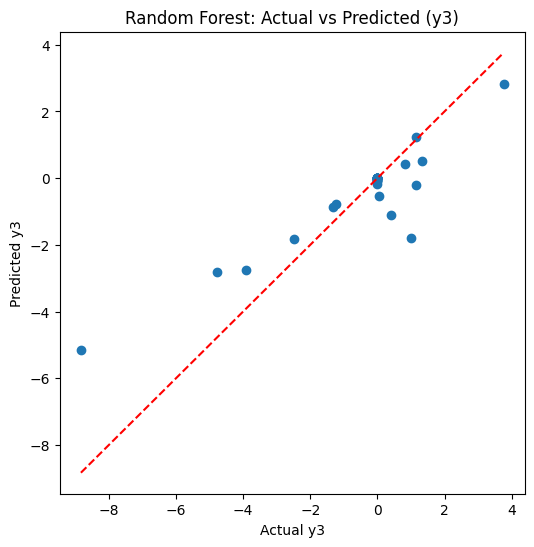

In [46]:
plt.figure(figsize=(6,6))

plt.scatter(
    Y['y3'],
    rf_pred[:,2]
)

plt.plot(
    [Y['y3'].min(), Y['y3'].max()],
    [Y['y3'].min(), Y['y3'].max()],
    'r--'
)

plt.xlabel("Actual y3")

plt.ylabel("Predicted y3")

plt.title("Random Forest: Actual vs Predicted (y3)")

plt.show()

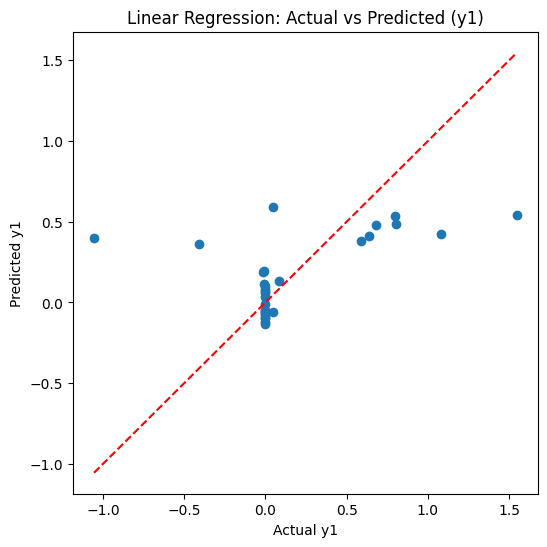

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    Y['y1'],
    lr_pred[:,0]
)

plt.plot(
    [Y['y1'].min(), Y['y1'].max()],
    [Y['y1'].min(), Y['y1'].max()],
    'r--'
)

plt.xlabel("Actual y1")

plt.ylabel("Predicted y1")

plt.title("Linear Regression: Actual vs Predicted (y1)")

plt.show()

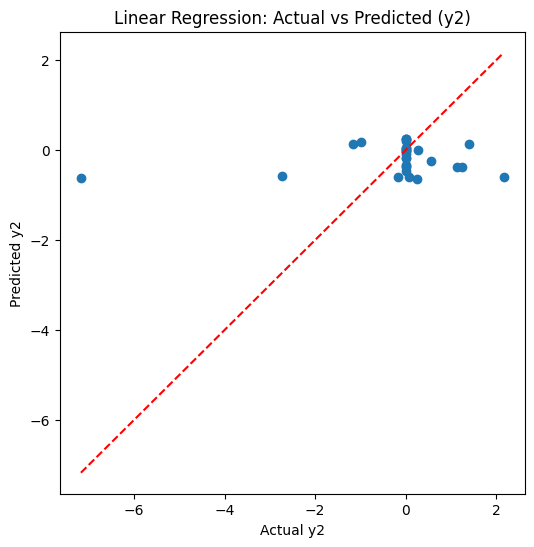

In [48]:
plt.figure(figsize=(6,6))

plt.scatter(
    Y['y2'],
    lr_pred[:,1]
)

plt.plot(
    [Y['y2'].min(), Y['y2'].max()],
    [Y['y2'].min(), Y['y2'].max()],
    'r--'
)

plt.xlabel("Actual y2")

plt.ylabel("Predicted y2")

plt.title("Linear Regression: Actual vs Predicted (y2)")

plt.show()

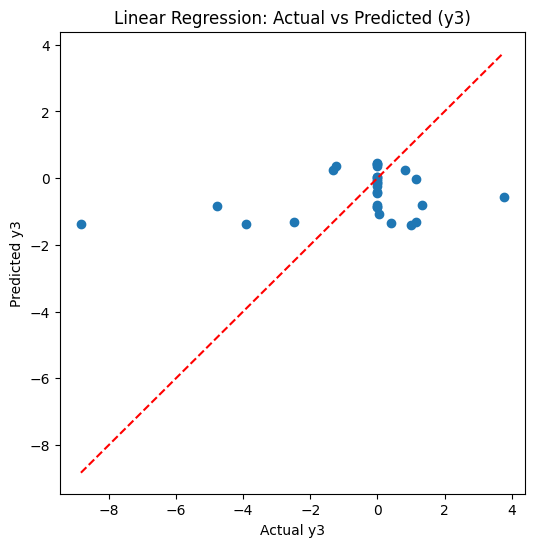

In [49]:
plt.figure(figsize=(6,6))

plt.scatter(
    Y['y3'],
    lr_pred[:,2]
)

plt.plot(
    [Y['y3'].min(), Y['y3'].max()],
    [Y['y3'].min(), Y['y3'].max()],
    'r--'
)

plt.xlabel("Actual y3")

plt.ylabel("Predicted y3")

plt.title("Linear Regression: Actual vs Predicted (y3)")

plt.show()

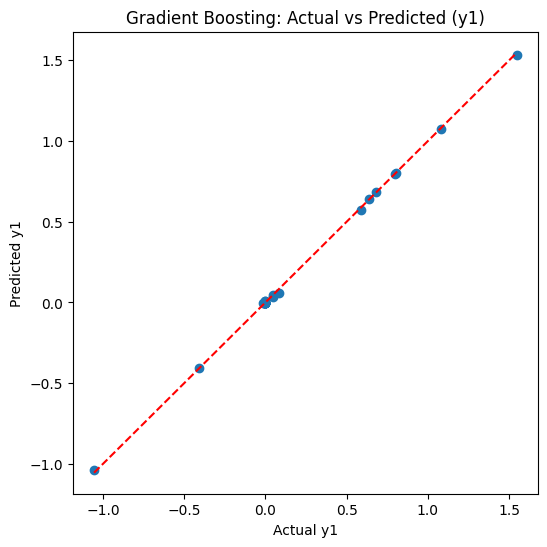

In [50]:
plt.figure(figsize=(6,6))

plt.scatter(
    Y['y1'],
    gb_pred[:,0]
)

plt.plot(
    [Y['y1'].min(), Y['y1'].max()],
    [Y['y1'].min(), Y['y1'].max()],
    'r--'
)

plt.xlabel("Actual y1")

plt.ylabel("Predicted y1")

plt.title("Gradient Boosting: Actual vs Predicted (y1)")

plt.show()

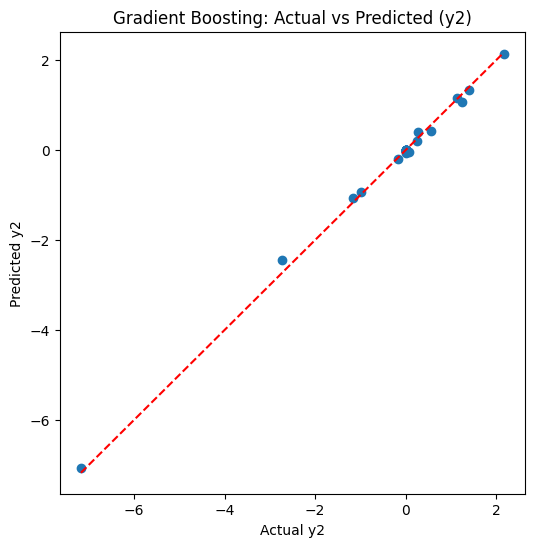

In [51]:
plt.figure(figsize=(6,6))

plt.scatter(
    Y['y2'],
    gb_pred[:,1]
)

plt.plot(
    [Y['y2'].min(), Y['y2'].max()],
    [Y['y2'].min(), Y['y2'].max()],
    'r--'
)

plt.xlabel("Actual y2")

plt.ylabel("Predicted y2")

plt.title("Gradient Boosting: Actual vs Predicted (y2)")

plt.show()

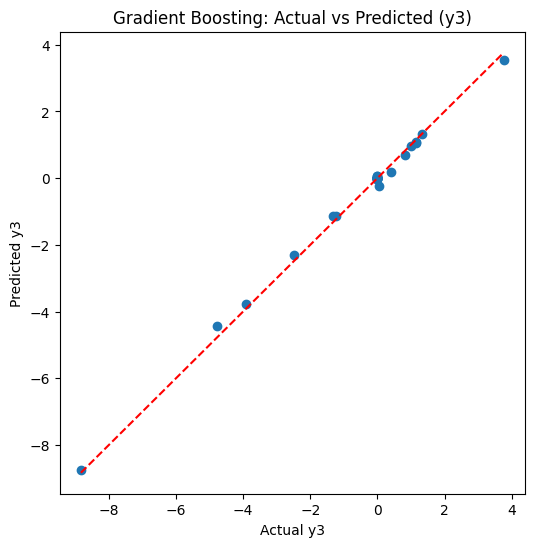

In [52]:
plt.figure(figsize=(6,6))

plt.scatter(
    Y['y3'],
    gb_pred[:,2]
)

plt.plot(
    [Y['y3'].min(), Y['y3'].max()],
    [Y['y3'].min(), Y['y3'].max()],
    'r--'
)

plt.xlabel("Actual y3")

plt.ylabel("Predicted y3")

plt.title("Gradient Boosting: Actual vs Predicted (y3)")

plt.show()

In [53]:
rf_residuals = Y - rf_pred

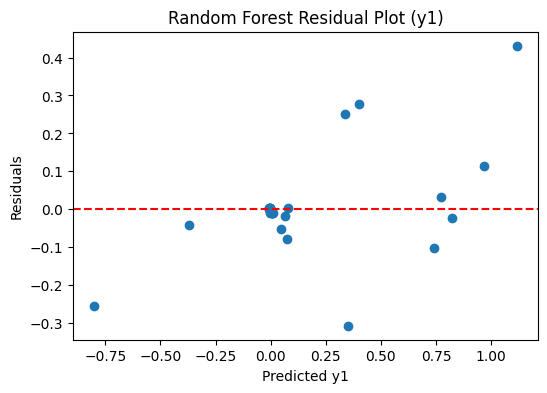

In [54]:
plt.figure(figsize=(6,4))

plt.scatter(
    rf_pred[:,0],
    rf_residuals['y1']
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted y1")

plt.ylabel("Residuals")

plt.title("Random Forest Residual Plot (y1)")

plt.show()

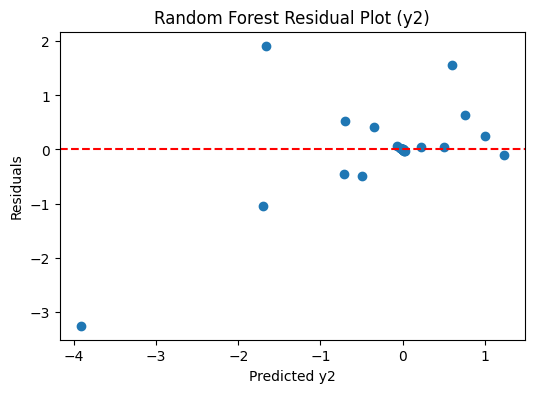

In [55]:
plt.figure(figsize=(6,4))

plt.scatter(
    rf_pred[:,1],
    rf_residuals['y2']
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted y2")

plt.ylabel("Residuals")

plt.title("Random Forest Residual Plot (y2)")

plt.show()

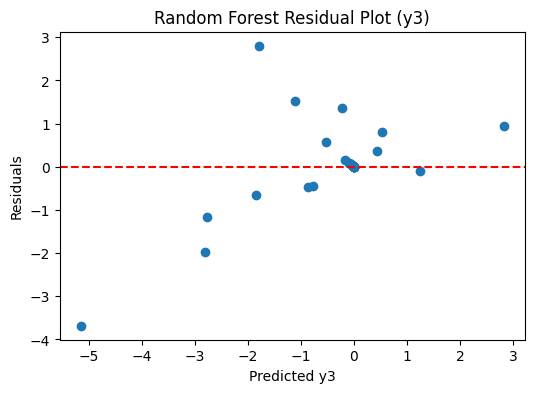

In [56]:
plt.figure(figsize=(6,4))

plt.scatter(
    rf_pred[:,2],
    rf_residuals['y3']
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted y3")

plt.ylabel("Residuals")

plt.title("Random Forest Residual Plot (y3)")

plt.show()

In [57]:
from sklearn.model_selection import GridSearchCV

In [58]:
param_grid = {

    'n_estimators': [50, 100, 200],

    'max_depth': [2, 3, 5, 7],

    'min_samples_split': [2, 4, 6],

    'min_samples_leaf': [1, 2, 4]

}

In [59]:
grid_rf = GridSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=kf,

    scoring='r2',

    n_jobs=-1

)

In [60]:
grid_rf.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [61]:
print(grid_rf.best_params_)

print(grid_rf.best_score_)

{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}
-1.2357597610440911


In [62]:
best_rf = grid_rf.best_estimator_

best_rf.fit(X, Y)

best_rf_pred = best_rf.predict(X)

In [63]:
param_grid_gb = {

    'estimator__n_estimators': [50, 100, 200],

    'estimator__learning_rate': [0.01, 0.05, 0.1],

    'estimator__max_depth': [1, 2, 3],

    'estimator__subsample': [0.6, 0.8, 1.0]

}

In [64]:
grid_gb = GridSearchCV(

    estimator=MultiOutputRegressor(
        GradientBoostingRegressor(
            random_state=42
        )
    ),

    param_grid=param_grid_gb,

    cv=kf,

    scoring='r2',

    n_jobs=-1

)

In [65]:
grid_gb.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultiOutputRe...dom_state=42))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__learning_rate': [0.01, 0.05, ...], 'estimator__max_depth': [1, 2, ...], 'estimator__n_estimators': [50, 100, ...], 'estimator__subsample': [0.6, 0.8, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher,

In [66]:
print(grid_gb.best_params_)

print(grid_gb.best_score_)

{'estimator__learning_rate': 0.01, 'estimator__max_depth': 2, 'estimator__n_estimators': 200, 'estimator__subsample': 1.0}
-0.9679234243469612


In [67]:
from sklearn.model_selection import learning_curve

In [69]:
best_gb = grid_gb.best_estimator_

In [70]:
train_sizes, train_scores, val_scores = learning_curve(

    estimator=best_gb,

    X=X,

    y=Y,

    cv=kf,

    scoring='r2',

    train_sizes=np.linspace(0.2, 1.0, 10),

    n_jobs=-1

)

In [71]:
train_mean = np.mean(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)

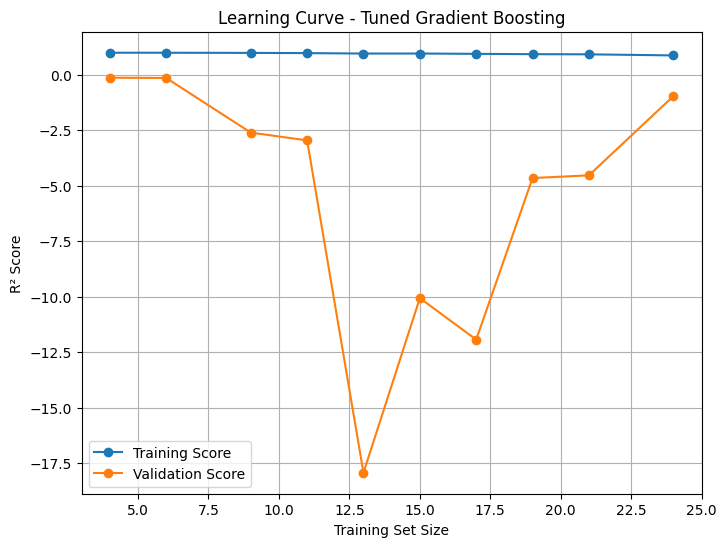

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Score'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation Score'
)

plt.xlabel("Training Set Size")

plt.ylabel("R² Score")

plt.title("Learning Curve - Tuned Gradient Boosting")

plt.legend()

plt.grid(True)

plt.show()

In [73]:
best_rf = grid_rf.best_estimator_

In [74]:
importance = best_rf.feature_importances_

print(importance)

[0.64132784 0.35867216]


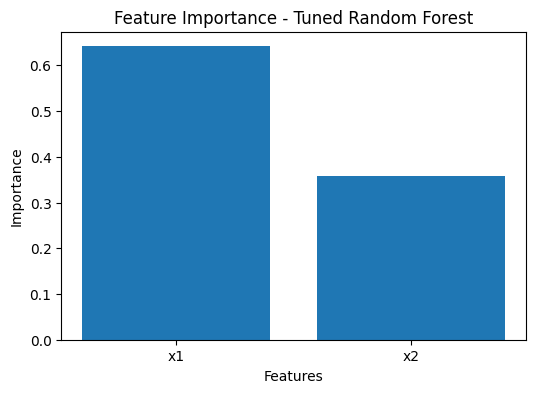

In [75]:
features = ['x1', 'x2']

plt.figure(figsize=(6,4))

plt.bar(features, importance)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance - Tuned Random Forest")

plt.show()

In [76]:
best_gb = grid_gb.best_estimator_

In [77]:
best_gb.fit(X, Y)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,GradientBoost...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performanc

In [78]:
X.iloc[[0]]

,x1,x2
0,3.920868e-07,0.509609


In [79]:
sample_input = X.iloc[[0]]

predicted_output = best_gb.predict(sample_input)

print("Input:")

print(sample_input)

print("\nActual Output:")

print(Y.iloc[[0]])

print("\nPredicted Output:")

print(predicted_output)

Input:
             x1        x2
0  3.920868e-07  0.509609

Actual Output:
         y1        y2        y3
0  0.044084  0.259264  1.014065

Predicted Output:
[[0.12910212 0.13753043 0.78078286]]


In [80]:
actual = Y.iloc[0].values

predicted = predicted_output[0]

percentage_error = np.abs(
    (actual - predicted) / actual
) * 100

print(percentage_error)

[192.85569942  46.95356218  23.00464871]


In [81]:
indices = [0, 3, 7, 12, 18, 25]

results = []

for i in indices:

    actual = Y.iloc[i].values

    pred = best_gb.predict(
        X.iloc[[i]]
    )[0]

    row = {

        'Sample': i,

        'Actual_y1': actual[0],
        'Pred_y1': pred[0],
        'Error_y1': abs(actual[0] - pred[0]),

        'Actual_y2': actual[1],
        'Pred_y2': pred[1],
        'Error_y2': abs(actual[1] - pred[1]),

        'Actual_y3': actual[2],
        'Pred_y3': pred[2],
        'Error_y3': abs(actual[2] - pred[2]),
    }

    results.append(row)

results_df = pd.DataFrame(results)

print(results_df)

   Sample  Actual_y1   Pred_y1  Error_y1  Actual_y2   Pred_y2  Error_y2  \
0       0   0.044084  0.129102  0.085018   0.259264  0.137530  0.121734   
1       3  -0.001319  0.017306  0.018625   0.000218 -0.034784  0.035002   
2       7  -0.002624  0.017306  0.019930   0.000550 -0.034784  0.035334   
3      12   0.045297  0.107959  0.062662   0.074021 -0.169365  0.243387   
4      18  -0.004900  0.107959  0.112859   0.005804 -0.034784  0.040588   
5      25  -0.003563  0.017306  0.020869   0.000830 -0.034784  0.035614   

   Actual_y3   Pred_y3  Error_y3  
0   1.014065  0.780783  0.233282  
1  -0.000049 -0.028525  0.028476  
2  -0.000161 -0.076171  0.076010  
3  -3.928431 -2.719622  1.208810  
4   0.055016 -1.009427  1.064443  
5  -0.000272 -0.076171  0.075899  


In [1]:
x1=float(input("Enter x1: "))
x2=float(input("Enter x2: "))

new_input=pd.DataFrame({
    'x1': [x1],
    'x2': [x2]
})

prediction = best_gb.predict(new_input)

print("\nPredicted Outputs:")

print(f"y1={prediction[0][0]}")
print(f"y1={prediction[0][1]}")
print(f"y1={prediction[0][2]}")

ValueError: could not convert string to float: ''